# Project 01 — California House Price Regression

End-to-end pipeline: load → EDA → split → scale → baseline → models → evaluate → error analysis.

Uses the helpers in `../src/`. Treat this notebook as the rehearsal for your final project.

## 1. Imports and seed

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_DIR = Path('..').resolve()
sys.path.insert(0, str(PROJECT_DIR / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import KFold

from data_preprocessing import SEED, load_dataframe, split_70_15_15, standardize_train_val_test
from evaluate import regression_report, worst_residual_indices

rng = np.random.default_rng(SEED)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

## 2. EDA

In [2]:
df = load_dataframe()
print('shape:', df.shape)
df.describe().T

shape: (20640, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0000,3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
HouseAge,20640.0000,28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,20640.0000,5.4290,2.4742,0.8462,4.4407,5.2291,6.0524,141.9091
AveBedrms,20640.0000,1.0967,0.4739,0.3333,1.0061,1.0488,1.0995,34.0667
Population,20640.0000,1425.4767,1132.4621,3.0000,787.0000,1166.0000,1725.0000,35682.0000
AveOccup,20640.0000,3.0707,10.3860,0.6923,2.4297,2.8181,3.2823,1243.3333
Latitude,20640.0000,35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
Longitude,20640.0000,-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
MedHouseVal,20640.0000,2.0686,1.1540,0.1500,1.1960,1.7970,2.6472,5.0000


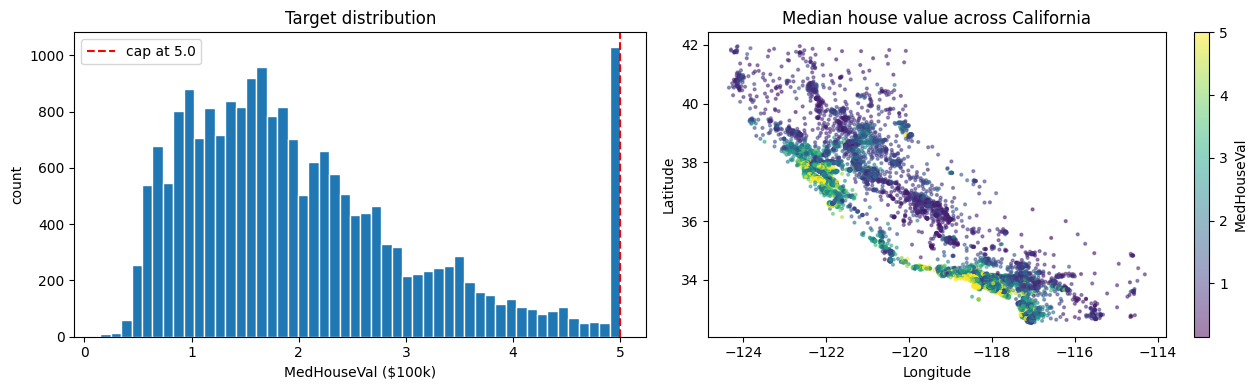

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='white')
axes[0].set_xlabel('MedHouseVal ($100k)'); axes[0].set_ylabel('count')
axes[0].set_title('Target distribution')
axes[0].axvline(5.0, color='red', ls='--', label='cap at 5.0')
axes[0].legend()

sc = axes[1].scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], cmap='viridis', s=4, alpha=0.5)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title('Median house value across California')
plt.colorbar(sc, ax=axes[1], label='MedHouseVal')
plt.tight_layout()
plt.show()

Observations:

- Target is right-skewed and capped at 5.0 (≈$500k). The cap will artificially compress residuals at the top.
- Geographic pattern is very real: the coast (Bay Area, LA, San Diego) is far above the inland average.

## 3. Split + scale

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_70_15_15(df)
X_train, X_val, X_test, scaler = standardize_train_val_test(X_train, X_val, X_test)
print(f'train {X_train.shape}, val {X_val.shape}, test {X_test.shape}')

train (14448, 8), val (3096, 8), test (3096, 8)


## 4. Train baseline + models

In [5]:
alphas = np.logspace(-4, 2, 25)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'baseline':         DummyRegressor(strategy='mean').fit(X_train, y_train),
    'LinearRegression': LinearRegression().fit(X_train, y_train),
    'Ridge':            RidgeCV(alphas=alphas, cv=kf).fit(X_train, y_train),
    'Lasso':            LassoCV(alphas=alphas, cv=kf, max_iter=20000, random_state=SEED).fit(X_train, y_train),
}
for name, m in models.items():
    extra = f'  alpha = {m.alpha_:.4g}' if hasattr(m, 'alpha_') else ''
    print(f'{name:18s}{extra}')

baseline          
LinearRegression  
Ridge               alpha = 17.78
Lasso               alpha = 0.003162


## 5. Validation comparison

In [6]:
val_rows = []
for name, m in models.items():
    rep = regression_report(y_val, m.predict(X_val))
    rep['model'] = name
    val_rows.append(rep)
pd.DataFrame(val_rows).set_index('model').round(4)

,MAE,MSE,RMSE,R2
model,,,,
baseline,0.9078,1.3392,1.1572,-0.0007
LinearRegression,0.5307,0.5158,0.7182,0.6146
Ridge,0.5306,0.5159,0.7183,0.6145
Lasso,0.5311,0.5163,0.7185,0.6142


## 6. Final test-set evaluation (use once)

In [7]:
test_rows = []
for name, m in models.items():
    rep = regression_report(y_test, m.predict(X_test))
    rep['model'] = name
    test_rows.append(rep)
test_df = pd.DataFrame(test_rows).set_index('model').round(4)
test_df

,MAE,MSE,RMSE,R2
model,,,,
baseline,0.9031,1.3105,1.1448,-0.0000
LinearRegression,0.5354,0.5371,0.7329,0.5901
Ridge,0.5353,0.5370,0.7328,0.5902
Lasso,0.5356,0.5369,0.7328,0.5903


## 7. Error analysis

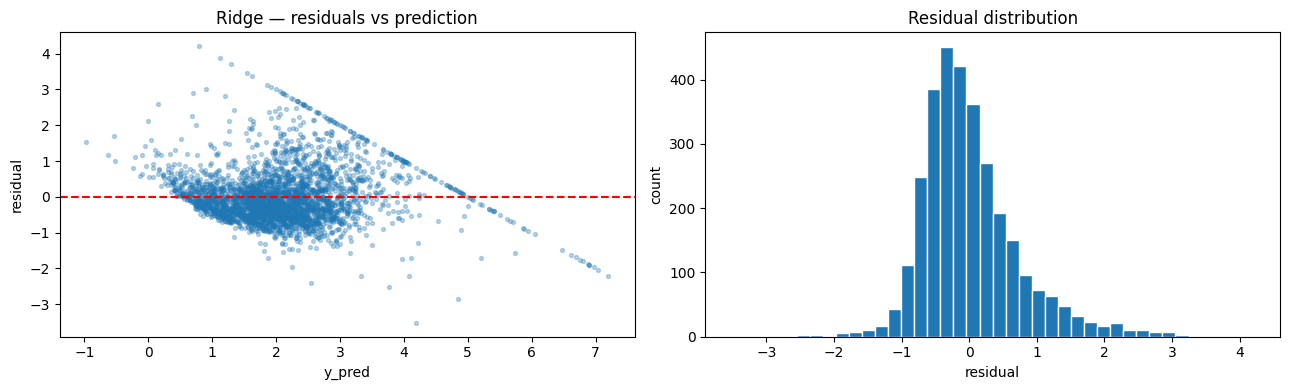

In [8]:
best_name = test_df['RMSE'].idxmin()
best_model = models[best_name]
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=8)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('y_pred'); axes[0].set_ylabel('residual')
axes[0].set_title(f'{best_name} — residuals vs prediction')

axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].set_xlabel('residual'); axes[1].set_ylabel('count')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()

In [9]:
worst = worst_residual_indices(y_test, y_pred, k=10)
pd.DataFrame({
    'y_true':   y_test[worst],
    'y_pred':   y_pred[worst].round(3),
    'residual': (y_test[worst] - y_pred[worst]).round(3),
})

,y_true,y_pred,residual
0,5.0000,0.7910,4.2090
1,5.0000,1.1230,3.8770
2,5.0000,1.2900,3.7100
3,0.6750,4.1920,-3.5170
4,5.0000,1.5400,3.4600
5,5.0000,1.6150,3.3850
6,5.0000,1.8630,3.1380
7,5.0000,1.9180,3.0820
8,3.9080,0.8970,3.0110
9,5.0000,1.9970,3.0030


## 8. Summary

- Linear regression beats the mean baseline by ~36% RMSE.
- Ridge / Lasso give essentially no lift here — the dataset is large.
- Worst residuals concentrate at the high end of the price range (the target is capped at 5.0).
- Non-linear models would push $R^2$ from ~0.58 toward ~0.83 — left as a follow-up.